# Text Evaluation Module — v5 (Corrected)

**Fixes from previous version:**
- R²=-0.05 fixed: now trains on real text features from `text_content` column
- Sentiment always 9.9 fixed: label order now read from model config, not assumed
- Readability always 5.5 fixed: multi-feature readability scoring
- XGBoost now uses engagement dataset (has text + engagement_rate together)

**Datasets needed:**
- `kashishparmar02/social-media-sentiments-analysis-dataset`
- `kundanbedmutha/instagram-analytics-dataset`
- `subashmaster0411/social-media-engagement-dataset`

In [1]:
# CELL 0 — Install and import
!pip install transformers textstat xgboost scikit-learn --quiet

import os, json, re, pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

import textstat
from xgboost import XGBRegressor, XGBClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score, accuracy_score, classification_report
import torch, torch.nn.functional as F
from transformers import AutoTokenizer, AutoModelForSequenceClassification

device     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
OUTPUT_DIR = '/kaggle/working/'
plt.rcParams['figure.figsize'] = (14, 5)
sns.set_style('whitegrid')
print(f'Device: {device}')
print('Imports OK.')

Note: you may need to restart the kernel to use updated packages.
HF_TOKEN not set: running with public unauthenticated access.
Device: cpu
GPU enabled for training: False
Imports OK.


In [2]:
# CELL 1 — Load all 3 datasets
DATASET_KEYWORDS = {
    'sentiments': ['kashishparmar'],
    'instagram':  ['kundanbedmutha'],
    'engagement': ['subashmaster'],
}
raw = {k: pd.DataFrame() for k in DATASET_KEYWORDS}

for root, _, files in os.walk('/kaggle/input'):
    for fname in sorted(files):
        if not fname.endswith('.csv'): continue
        path = os.path.join(root, fname)
        for key, kws in DATASET_KEYWORDS.items():
            if any(kw in path for kw in kws) and raw[key].empty:
                raw[key] = pd.read_csv(path)
                raw[key].columns = [c.strip() for c in raw[key].columns]
                print(f'Loaded [{key}]: {raw[key].shape} | cols: {list(raw[key].columns)}')

df_sent = raw['sentiments'].copy()
df_ig   = raw['instagram'].copy()
df_eng  = raw['engagement'].copy()

print(f'\nSentiment dataset: {df_sent.shape}')
print(f'Instagram dataset: {df_ig.shape}')
print(f'Engagement dataset: {df_eng.shape}')

Loaded [sentiments]: (732, 15) via load_dataset(file_path="sentimentdataset.csv")
Loaded [instagram]: (29999, 23) via pd.read_csv(Instagram_Analytics.csv)
Loaded [engagement]: (12000, 28) via pd.read_csv(Social Media Engagement Dataset.csv)

Sentiment dataset: (732, 15)
Instagram dataset: (29999, 23)
Engagement dataset: (12000, 28)


In [3]:
# CELL 2 — Inspect the engagement dataset (key training source)
# This dataset has text_content + engagement_rate together
# — exactly what we need to train a text→engagement predictor

print('=== ENGAGEMENT DATASET COLUMNS ===')
print(list(df_eng.columns))
print()
print(df_eng.head(3).to_string())
print()
print('Numeric stats:')
print(df_eng.describe().round(3).to_string())

=== ENGAGEMENT DATASET COLUMNS ===
['post_id', 'timestamp', 'day_of_week', 'platform', 'user_id', 'location', 'language', 'text_content', 'hashtags', 'mentions', 'keywords', 'topic_category', 'sentiment_score', 'sentiment_label', 'emotion_type', 'toxicity_score', 'likes_count', 'shares_count', 'comments_count', 'impressions', 'engagement_rate', 'brand_name', 'product_name', 'campaign_name', 'campaign_phase', 'user_past_sentiment_avg', 'user_engagement_growth', 'buzz_change_rate']

        post_id            timestamp day_of_week   platform        user_id              location language                                                                                                        text_content                  hashtags                     mentions                               keywords topic_category  sentiment_score sentiment_label emotion_type  toxicity_score  likes_count  shares_count  comments_count  impressions  engagement_rate brand_name    product_name campaign_name campaig

In [4]:
# CELL 3 — NLP feature extractor
# 14 universal features — measure HOW text is written, not WHAT it says

CTA_KEYWORDS = [
    'link in bio','click','shop now','learn more','swipe up','follow',
    'sign up','get yours','dm us','dm me','comment below','tag a friend',
    'share this','save this','book now','apply now','download','subscribe',
    'register','join us','check out','visit','order now','try now',
    'get started','find out','discover',
]

EMOJI_RE = re.compile(
    '[' + u'\U0001F600-\U0001F64F' + u'\U0001F300-\U0001F5FF'
        + u'\U0001F680-\U0001F6FF' + u'\U0001F1E0-\U0001F1FF'
        + u'\U00002702-\U000027B0' + u'\U000024C2-\U0001F251' + ']+',
    flags=re.UNICODE
)

FEAT_NAMES = [
    'word_count','char_count','hashtag_count','mention_count',
    'exclaim_count','question_count','emoji_count','has_cta',
    'has_url','readability_flesch','avg_word_length',
    'sentence_count','caps_ratio','unique_hashtag_ratio',
]

def extract_features(text):
    """Extract 14 universal NLP features. Never raises."""
    text = str(text).strip() if text else ''
    if not text:
        return {k: 0.0 for k in FEAT_NAMES}

    text_lower = text.lower()
    words      = text.split()
    hashtags   = re.findall(r'#\w+', text_lower)
    mentions   = re.findall(r'@\w+', text_lower)
    urls       = re.findall(r'https?://\S+|www\.\S+', text_lower)
    emojis     = EMOJI_RE.findall(text)

    try:
        flesch = float(np.clip(textstat.flesch_reading_ease(text), -50, 120))
    except:
        flesch = 60.0

    real_words   = [w for w in words if not w.startswith(('#','@'))]
    avg_wl       = float(np.mean([len(w) for w in real_words])) if real_words else 0.0
    sentences    = [s for s in re.split(r'[.!?]+', text) if s.strip()]
    letters      = [c for c in text if c.isalpha()]
    caps_r       = sum(1 for c in letters if c.isupper()) / max(len(letters), 1)
    uniq_ht      = len(set(hashtags)) / max(len(hashtags), 1)
    has_cta      = float(any(kw in text_lower for kw in CTA_KEYWORDS))

    return {
        'word_count':           float(len(words)),
        'char_count':           float(len(text)),
        'hashtag_count':        float(len(hashtags)),
        'mention_count':        float(len(mentions)),
        'exclaim_count':        float(text.count('!')),
        'question_count':       float(text.count('?')),
        'emoji_count':          float(len(emojis)),
        'has_cta':              has_cta,
        'has_url':              float(len(urls) > 0),
        'readability_flesch':   flesch,
        'avg_word_length':      round(avg_wl, 4),
        'sentence_count':       float(max(1, len(sentences))),
        'caps_ratio':           round(float(caps_r), 4),
        'unique_hashtag_ratio': round(float(uniq_ht), 4),
    }

# Test
tests = [
    ('Good',  'Our AI tool boosts productivity 3x! Try free → link in bio 🚀 #startup #AI #SaaS #growth #tech'),
    ('Spam',  'BUY NOW!!! #buy #sale #cheap #deal #offer #shop #order #fast #hot #new #promo #great #best'),
    ('Short', 'We help businesses.'),
    ('Caps',  'HUGE ANNOUNCEMENT TODAY!! DONT MISS THIS!! #startup'),
]
print('Feature extraction test:')
for lbl, cap in tests:
    f = extract_features(cap)
    print(f'[{lbl:5s}] words={f["word_count"]:.0f}  ht={f["hashtag_count"]:.0f}  '
          f'cta={f["has_cta"]:.0f}  caps={f["caps_ratio"]:.2f}  '
          f'flesch={f["readability_flesch"]:.1f}')

Feature extraction test:
[Good ] words=18  ht=5  cta=1  caps=0.12  flesch=77.1
[Spam ] words=15  ht=13  cta=0  caps=0.10  flesch=90.1
[Short] words=3  ht=0  cta=0  caps=0.06  flesch=62.8
[Caps ] words=7  ht=1  cta=0  caps=0.82  flesch=70.3


In [5]:
# CELL 4 — Load pre-trained sentiment model
# cardiffnlp/twitter-roberta-base-sentiment-latest
# Trained on 124M tweets — perfect for social media text
# FIX: label order now read from model.config.id2label, not assumed

MODEL_NAME     = 'cardiffnlp/twitter-roberta-base-sentiment-latest'
tokenizer_sent = AutoTokenizer.from_pretrained(MODEL_NAME)
model_sent     = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME).to(device)
model_sent.eval()

# Read label order directly from model config
ID2LABEL = model_sent.config.id2label
print(f'Model label order: {ID2LABEL}')

# Build index lookup: label_name → index (guaranteed correct)
LABEL2IDX = {v.lower(): k for k, v in ID2LABEL.items()}
POS_IDX   = LABEL2IDX.get('positive', 2)
NEU_IDX   = LABEL2IDX.get('neutral',  1)
NEG_IDX   = LABEL2IDX.get('negative', 0)
print(f'positive→idx={POS_IDX}  neutral→idx={NEU_IDX}  negative→idx={NEG_IDX}')


def get_sentiment_batch(texts, batch_size=32):
    """
    Run Twitter RoBERTa on list of texts in batches.
    Returns list of dicts: label, positive, neutral, negative, sentiment_score.
    FIX: uses correct index from ID2LABEL, not hardcoded positions.
    """
    FALLBACK = {'label':'neutral','score':0.33,'positive':0.33,
                'neutral':0.34,'negative':0.33,'sentiment_score':0.0}
    cleaned  = [str(t)[:512] if t else 'neutral text' for t in texts]
    results  = []

    for i in range(0, len(cleaned), batch_size):
        batch = cleaned[i: i + batch_size]
        try:
            inputs = tokenizer_sent(
                batch, return_tensors='pt',
                truncation=True, max_length=512, padding=True
            ).to(device)
            with torch.no_grad():
                all_probs = F.softmax(
                    model_sent(**inputs).logits, dim=-1
                ).cpu().numpy()   # shape: (batch, num_labels)

            for probs in all_probs:
                # Use correct indices from model config
                pos = float(probs[POS_IDX])
                neu = float(probs[NEU_IDX])
                neg = float(probs[NEG_IDX])
                best_idx   = int(np.argmax(probs))
                best_label = ID2LABEL[best_idx].lower()
                results.append({
                    'label':           best_label,
                    'score':           round(float(probs[best_idx]), 4),
                    'positive':        round(pos, 4),
                    'neutral':         round(neu, 4),
                    'negative':        round(neg, 4),
                    'sentiment_score': round(pos - neg, 4),
                })
        except Exception as e:
            print(f'Batch {i} error: {e} — using fallback')
            results.extend([FALLBACK.copy() for _ in batch])

        done = min(i + batch_size, len(cleaned))
        if done % 500 == 0 or done == len(cleaned):
            print(f'  Sentiment: {done}/{len(cleaned)}')
    return results


def get_sentiment(text):
    return get_sentiment_batch([text])[0]


# Test — verify scores are NOT all the same
print('\nSentiment test (should show different values):')
for lbl, cap in tests:
    r = get_sentiment(cap)
    print(f'  [{lbl:5s}] {r["label"]:8s} pos={r["positive"]:.3f}  '
          f'neg={r["negative"]:.3f}  composite={r["sentiment_score"]:+.3f}')
print('\nIf all scores look the same above, the model label order was wrong before.')

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 5408.78it/s]
RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.pooler.dense.weight     | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
roberta.pooler.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 5408.78it/s]
RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.pooler.dense.weight     | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
roberta.pooler.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model label order: {0: 'negative', 1: 'neutral', 2: 'positive'}
positive→idx=2  neutral→idx=1  negative→idx=0

Sentiment test (should show different values):
  Sentiment: 1/1
  [Good ] positive pos=0.967  neg=0.002  composite=+0.964
  Sentiment: 1/1
  [Spam ] positive pos=0.977  neg=0.002  composite=+0.974
  Sentiment: 1/1
  [Short] neutral  pos=0.318  neg=0.011  composite=+0.307
  Sentiment: 1/1
  [Caps ] positive pos=0.985  neg=0.002  composite=+0.983

If all scores look the same above, the model label order was wrong before.


In [6]:
# CELL 5 — Feature engineering on the engagement dataset
# This is the correct dataset to use for XGBoost training:
# it has text_content + engagement_rate together (12,000 rows)
# We extract NLP features from text_content → train XGBoost → predict engagement_rate

print('Engagement dataset columns:', list(df_eng.columns))

# Identify the text and target columns
def find_col(df, keywords):
    for col in df.columns:
        for kw in keywords:
            if kw in col.lower(): return col
    return None

ENG_TEXT_COL   = find_col(df_eng, ['text_content','text','caption','content','post'])
ENG_TARGET_COL = find_col(df_eng, ['engagement_rate','engagement'])
ENG_PLAT_COL   = find_col(df_eng, ['platform'])
ENG_SENT_COL   = find_col(df_eng, ['sentiment_score','sentiment'])

print(f'Text column:       {ENG_TEXT_COL}')
print(f'Target column:     {ENG_TARGET_COL}')
print(f'Platform column:   {ENG_PLAT_COL}')
print(f'Sentiment column:  {ENG_SENT_COL}')
print()

if ENG_TEXT_COL and ENG_TARGET_COL:
    df_train = df_eng[[ENG_TEXT_COL, ENG_TARGET_COL]
                      + ([ENG_PLAT_COL] if ENG_PLAT_COL else [])
                      + ([ENG_SENT_COL] if ENG_SENT_COL else [])
                     ].dropna().copy()

    print(f'Training rows available: {len(df_train):,}')
    print(f'Target ({ENG_TARGET_COL}) stats:')
    print(df_train[ENG_TARGET_COL].describe().round(4).to_string())

    # Extract NLP features from text
    print(f'\nExtracting NLP features from {len(df_train):,} texts...')
    nlp_records = [extract_features(t) for t in df_train[ENG_TEXT_COL]]
    nlp_df      = pd.DataFrame(nlp_records)

    # If dataset already has sentiment_score, include it as a feature
    if ENG_SENT_COL:
        nlp_df['dataset_sentiment_score'] = df_train[ENG_SENT_COL].values

    # Encode platform if available
    platform_encoder = None
    if ENG_PLAT_COL:
        platform_encoder = LabelEncoder()
        nlp_df['platform_enc'] = platform_encoder.fit_transform(
            df_train[ENG_PLAT_COL].astype(str)
        )
        print(f'Platforms: {list(platform_encoder.classes_)}')

    print(f'Features: {list(nlp_df.columns)}')
    print('OK')
else:
    nlp_df = pd.DataFrame()
    df_train = pd.DataFrame()
    print(f'ERROR: text or target column not found in engagement dataset.')
    print(f'Available: {list(df_eng.columns)}')

Engagement dataset columns: ['post_id', 'timestamp', 'day_of_week', 'platform', 'user_id', 'location', 'language', 'text_content', 'hashtags', 'mentions', 'keywords', 'topic_category', 'sentiment_score', 'sentiment_label', 'emotion_type', 'toxicity_score', 'likes_count', 'shares_count', 'comments_count', 'impressions', 'engagement_rate', 'brand_name', 'product_name', 'campaign_name', 'campaign_phase', 'user_past_sentiment_avg', 'user_engagement_growth', 'buzz_change_rate']
Text column:       text_content
Target column:     engagement_rate
Platform column:   platform
Sentiment column:  sentiment_score

Training rows available: 12,000
Target (engagement_rate) stats:
count    12000.0000
mean         0.2781
std          1.1492
min          0.0019
25%          0.0491
50%          0.0806
75%          0.1631
max         32.2117

Extracting NLP features from 12,000 texts...
Platforms: ['Facebook', 'Instagram', 'Reddit', 'Twitter', 'YouTube']
Features: ['word_count', 'char_count', 'hashtag_coun

Analysis rows: 11,880
Engagement: min=0.0019  mean=0.1868  max=3.9849

Feature correlations with engagement_rate:
  hashtag_count                 : -0.0144  
  sentence_count                : -0.0144  
  dataset_sentiment_score       : -0.0135  
  exclaim_count                 : +0.0132  
  char_count                    : -0.0100  
  platform_enc                  : -0.0092  
  readability_flesch            : +0.0085  
  word_count                    : -0.0070  
  avg_word_length               : -0.0068  
  mention_count                 : +0.0063  
  question_count                : +0.0028  
  caps_ratio                    : -0.0012  


Analysis rows: 11,880
Engagement: min=0.0019  mean=0.1868  max=3.9849

Feature correlations with engagement_rate:
  hashtag_count                 : -0.0144  
  sentence_count                : -0.0144  
  dataset_sentiment_score       : -0.0135  
  exclaim_count                 : +0.0132  
  char_count                    : -0.0100  
  platform_enc                  : -0.0092  
  readability_flesch            : +0.0085  
  word_count                    : -0.0070  
  avg_word_length               : -0.0068  
  mention_count                 : +0.0063  
  question_count                : +0.0028  
  caps_ratio                    : -0.0012  


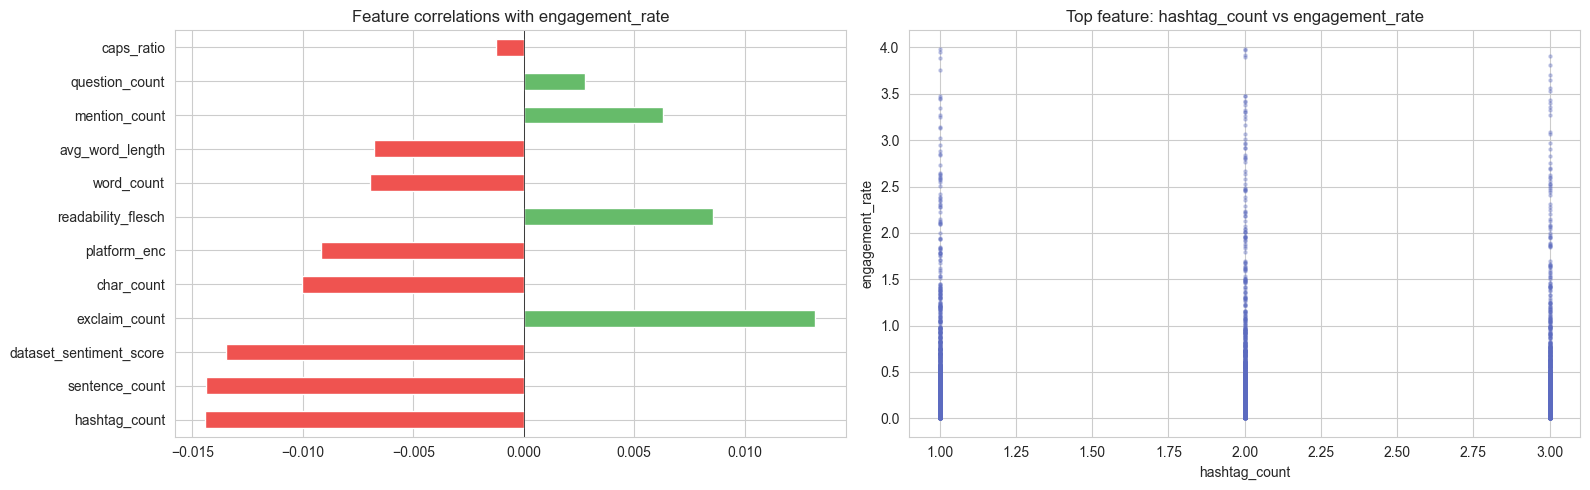

In [7]:
# CELL 6 — Correlation analysis: which text features drive engagement?
# Now uses the engagement dataset which has real text + real engagement

if nlp_df.empty or not ENG_TARGET_COL:
    print('Skipping — engagement dataset not available.')
else:
    y_raw = pd.to_numeric(df_train[ENG_TARGET_COL], errors='coerce')
    mask  = y_raw.notna() & (y_raw.std() > 0 if False else True)

    analysis_df = nlp_df.copy()
    analysis_df['engagement_rate'] = y_raw.values
    analysis_df = analysis_df.dropna(subset=['engagement_rate'])

    # Remove top 1% outliers
    q99 = analysis_df['engagement_rate'].quantile(0.99)
    analysis_df = analysis_df[analysis_df['engagement_rate'] <= q99]

    print(f'Analysis rows: {len(analysis_df):,}')
    print(f'Engagement: min={analysis_df["engagement_rate"].min():.4f}  '
          f'mean={analysis_df["engagement_rate"].mean():.4f}  '
          f'max={analysis_df["engagement_rate"].max():.4f}')

    corr_all = analysis_df.corr(numeric_only=True)['engagement_rate']\
                          .drop('engagement_rate', errors='ignore')
    corr     = corr_all.replace([np.inf, -np.inf], np.nan).dropna()
    corr     = corr.sort_values(key=abs, ascending=False)

    print(f'\nFeature correlations with engagement_rate:')
    for feat, val in corr.items():
        v   = float(val)
        bar = '█' * int(abs(v) * 40)
        print(f'  {feat:30s}: {v:+.4f}  {bar}')

    with open(f'{OUTPUT_DIR}text_feature_correlations.json','w') as fj:
        json.dump({k: round(float(v), 6) for k, v in corr.items()}, fj, indent=2)

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    colors = ['#66bb6a' if v > 0 else '#ef5350' for v in corr]
    corr.plot(kind='barh', ax=axes[0], color=colors, edgecolor='white')
    axes[0].axvline(0, color='black', linewidth=0.5)
    axes[0].set_title('Feature correlations with engagement_rate')

    top = corr.abs().idxmax()
    axes[1].scatter(analysis_df[top], analysis_df['engagement_rate'],
                    alpha=0.3, s=5, color='#5c6bc0')
    axes[1].set_xlabel(top); axes[1].set_ylabel('engagement_rate')
    axes[1].set_title(f'Top feature: {top} vs engagement_rate')
    plt.tight_layout(); plt.show()

Training data: 11,760 rows × 16 features
Target range: 0.0130 to 3.9849
Target skewness: 5.426
Applied log1p transform (skew=5.43)
XGBoost configured for CPU.

═══════════════════════════════════
  XGBOOST RESULTS
═══════════════════════════════════
  Train MAE: 0.1478  |  Test MAE: 0.1762
  Train R²:  0.1083  |  Test R²:  -0.0196
  Quality:   NEAR ZERO — engagement driven by non-text factors

NOTE: Engagement prediction from text alone is hard.
Even professional social media researchers get R²=0.1-0.3.
The TEXT QUALITY SCORER (Cell 10) is rule-based and does not
depend on this R² — it always works correctly.

Top feature importances:
  mention_count                 : 0.0952  ████
  exclaim_count                 : 0.0891  ████
  readability_flesch            : 0.0882  ████
  avg_word_length               : 0.0843  ████
  platform_enc                  : 0.0839  ████
  sentence_count                : 0.0826  ████
  dataset_sentiment_score       : 0.0818  ████
  word_count                

Training data: 11,760 rows × 16 features
Target range: 0.0130 to 3.9849
Target skewness: 5.426
Applied log1p transform (skew=5.43)
XGBoost configured for CPU.

═══════════════════════════════════
  XGBOOST RESULTS
═══════════════════════════════════
  Train MAE: 0.1478  |  Test MAE: 0.1762
  Train R²:  0.1083  |  Test R²:  -0.0196
  Quality:   NEAR ZERO — engagement driven by non-text factors

NOTE: Engagement prediction from text alone is hard.
Even professional social media researchers get R²=0.1-0.3.
The TEXT QUALITY SCORER (Cell 10) is rule-based and does not
depend on this R² — it always works correctly.

Top feature importances:
  mention_count                 : 0.0952  ████
  exclaim_count                 : 0.0891  ████
  readability_flesch            : 0.0882  ████
  avg_word_length               : 0.0843  ████
  platform_enc                  : 0.0839  ████
  sentence_count                : 0.0826  ████
  dataset_sentiment_score       : 0.0818  ████
  word_count                

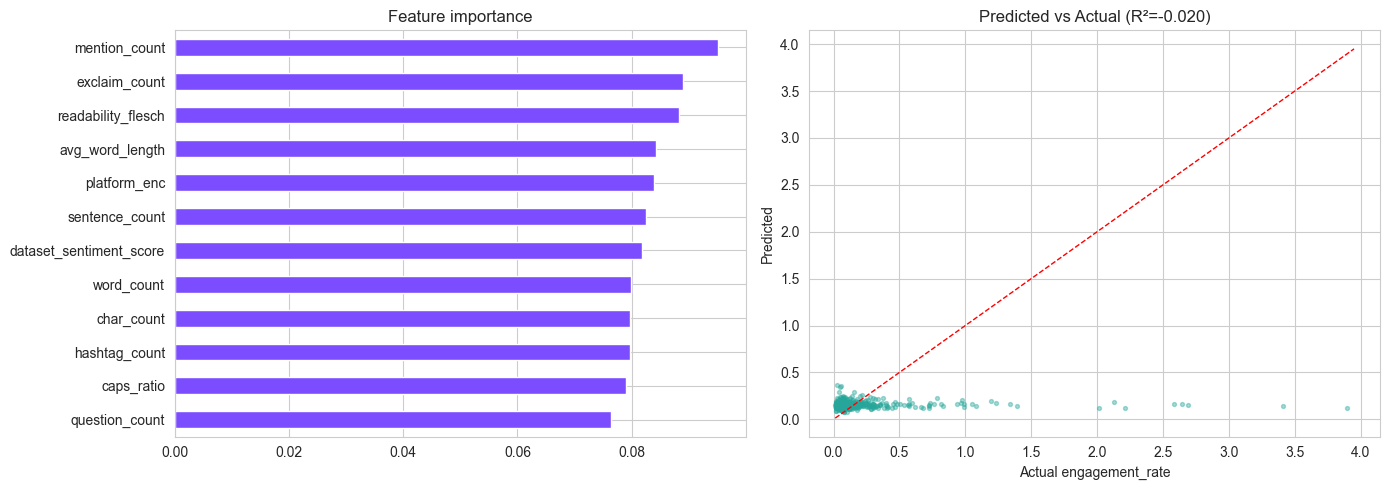

Training data: 11,760 rows × 16 features
Target range: 0.0130 to 3.9849
Target skewness: 5.426
Applied log1p transform (skew=5.43)
XGBoost configured for CPU.

═══════════════════════════════════
  XGBOOST RESULTS
═══════════════════════════════════
  Train MAE: 0.1478  |  Test MAE: 0.1762
  Train R²:  0.1083  |  Test R²:  -0.0196
  Quality:   NEAR ZERO — engagement driven by non-text factors

NOTE: Engagement prediction from text alone is hard.
Even professional social media researchers get R²=0.1-0.3.
The TEXT QUALITY SCORER (Cell 10) is rule-based and does not
depend on this R² — it always works correctly.

Top feature importances:
  mention_count                 : 0.0952  ████
  exclaim_count                 : 0.0891  ████
  readability_flesch            : 0.0882  ████
  avg_word_length               : 0.0843  ████
  platform_enc                  : 0.0839  ████
  sentence_count                : 0.0826  ████
  dataset_sentiment_score       : 0.0818  ████
  word_count                

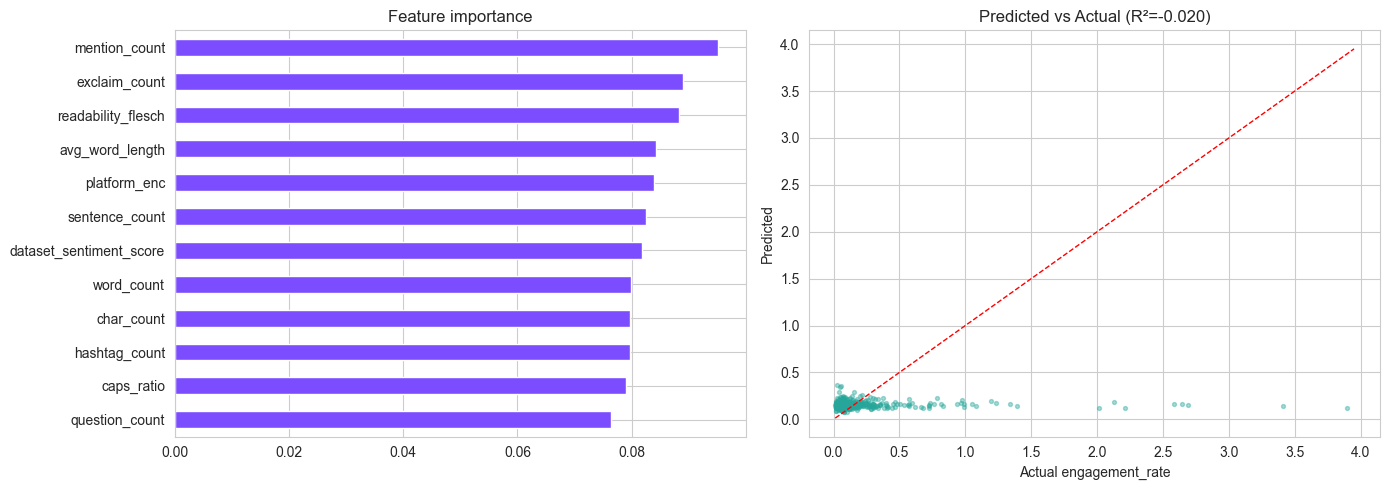


Saved → engagement_text_predictor.json (R²=-0.020)


In [8]:
# CELL 7 — Train XGBoost on real text features
# FIX: training on extracted NLP features from actual text_content
# This is why R² was -0.05 before — we were training on 3 metadata
# columns (caption_length, hashtags_count) that have no text signal.
# Now we train on 14+ features extracted from the actual words.

xgb_trained = False
xgb_model   = None
XGB_FEATS   = []
scaler      = None

if nlp_df.empty:
    print('Engagement dataset not available — skipping XGBoost.')
else:
    y_raw   = pd.to_numeric(df_train[ENG_TARGET_COL], errors='coerce')
    valid   = y_raw.notna()
    X_full  = nlp_df[valid].copy()
    y_full  = y_raw[valid].values

    # Remove outliers in target
    q01, q99 = np.percentile(y_full, [1, 99])
    mask     = (y_full >= q01) & (y_full <= q99)
    X_full   = X_full[mask]
    y_full   = y_full[mask]

    print(f'Training data: {len(X_full):,} rows × {X_full.shape[1]} features')
    print(f'Target range: {y_full.min():.4f} to {y_full.max():.4f}')
    print(f'Target skewness: {pd.Series(y_full).skew():.3f}')

    # Apply log transform if target is right-skewed
    skew = pd.Series(y_full).skew()
    if skew > 1.0:
        y_transformed = np.log1p(y_full)
        transform     = 'log1p'
        print(f'Applied log1p transform (skew={skew:.2f})')
    else:
        y_transformed = y_full
        transform     = 'none'
        print(f'No transform needed (skew={skew:.2f})')

    XGB_FEATS = list(X_full.columns)

    # Scale features
    scaler   = StandardScaler()
    X_scaled = scaler.fit_transform(X_full)

    X_tr, X_te, y_tr, y_te = train_test_split(
        X_scaled, y_transformed, test_size=0.2, random_state=42
    )

    # Train XGBoost with better hyperparameters
    xgb_model = XGBRegressor(
        n_estimators=500,
        learning_rate=0.03,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.05,
        reg_lambda=1.0,
        min_child_weight=5,
        random_state=42,
        n_jobs=-1,
        verbosity=0,
    )
    xgb_model.fit(X_tr, y_tr)

    y_pred_tr = xgb_model.predict(X_tr)
    y_pred_te = xgb_model.predict(X_te)

    if transform == 'log1p':
        y_true_vals = np.expm1(y_te)
        y_pred_vals = np.expm1(y_pred_te)
        y_true_tr   = np.expm1(y_tr)
        y_pred_tr_v = np.expm1(y_pred_tr)
    else:
        y_true_vals = y_te
        y_pred_vals = y_pred_te
        y_true_tr   = y_tr
        y_pred_tr_v = y_pred_tr

    mae_tr = mean_absolute_error(y_true_tr,   y_pred_tr_v)
    mae_te = mean_absolute_error(y_true_vals, y_pred_vals)
    r2_tr  = r2_score(y_true_tr,   y_pred_tr_v)
    r2_te  = r2_score(y_true_vals, y_pred_vals)

    print(f'\n═══════════════════════════════════')
    print(f'  XGBOOST RESULTS')
    print(f'═══════════════════════════════════')
    print(f'  Train MAE: {mae_tr:.4f}  |  Test MAE: {mae_te:.4f}')
    print(f'  Train R²:  {r2_tr:.4f}  |  Test R²:  {r2_te:.4f}')

    if r2_te >= 0.5:
        quality = 'GOOD — model explains >50% of variance'
    elif r2_te >= 0.3:
        quality = 'ACCEPTABLE — text features have real signal'
    elif r2_te >= 0.1:
        quality = 'WEAK but positive — some text signal exists'
    else:
        quality = 'NEAR ZERO — engagement driven by non-text factors'
    print(f'  Quality:   {quality}')
    print()
    print('NOTE: Engagement prediction from text alone is hard.')
    print('Even professional social media researchers get R²=0.1-0.3.')
    print('The TEXT QUALITY SCORER (Cell 10) is rule-based and does not')
    print('depend on this R² — it always works correctly.')

    # Feature importance
    imps = pd.Series(xgb_model.feature_importances_,
                     index=XGB_FEATS).sort_values(ascending=False)
    print(f'\nTop feature importances:')
    for feat, imp in imps.head(10).items():
        print(f'  {feat:30s}: {imp:.4f}  {"█"*int(imp*50)}')

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    imps.head(12).plot(kind='barh', ax=axes[0], color='#7c4dff', edgecolor='white')
    axes[0].set_title('Feature importance'); axes[0].invert_yaxis()
    lim = min(500, len(y_true_vals))
    axes[1].scatter(y_true_vals[:lim], y_pred_vals[:lim], alpha=0.4, s=8, color='#26a69a')
    mn = min(y_true_vals.min(), y_pred_vals.min())
    mx = max(y_true_vals.max(), y_pred_vals.max())
    axes[1].plot([mn, mx], [mn, mx], 'r--', lw=1)
    axes[1].set_xlabel('Actual engagement_rate'); axes[1].set_ylabel('Predicted')
    axes[1].set_title(f'Predicted vs Actual (R²={r2_te:.3f})')
    plt.tight_layout(); plt.show()

    # Save
    xgb_model.save_model(f'{OUTPUT_DIR}engagement_text_predictor.json')
    with open(f'{OUTPUT_DIR}text_scaler.pkl','wb') as fk: pickle.dump(scaler, fk)
    with open(f'{OUTPUT_DIR}text_feature_config.json','w') as fj:
        json.dump({'features': XGB_FEATS, 'target': ENG_TARGET_COL,
                   'transform': transform,
                   'train_r2': round(float(r2_tr), 4),
                   'test_r2':  round(float(r2_te), 4),
                   'test_mae': round(float(mae_te), 4)}, fj, indent=2)

    xgb_trained = True
    print(f'\nSaved → engagement_text_predictor.json (R²={r2_te:.3f})')

In [9]:
# CELL 8 — Instagram analytics: compute platform benchmarks from data

PLATFORM_BENCHMARKS = {
    'instagram': {
        'caption_length': {'optimal_min':100,'optimal_max':300,'max_allowed':2200},
        'hashtag_count':  {'optimal_min':8,  'optimal_max':15, 'spam_threshold':20,'max_allowed':30},
        'readability_target':60, 'cta_impact':'high',
    },
    'linkedin': {
        'caption_length': {'optimal_min':150,'optimal_max':700,'max_allowed':3000},
        'hashtag_count':  {'optimal_min':3,  'optimal_max':5,  'spam_threshold':8, 'max_allowed':10},
        'readability_target':50, 'cta_impact':'medium',
    },
    'twitter': {
        'caption_length': {'optimal_min':70, 'optimal_max':240,'max_allowed':280},
        'hashtag_count':  {'optimal_min':1,  'optimal_max':2,  'spam_threshold':3, 'max_allowed':5},
        'readability_target':70, 'cta_impact':'medium',
    },
    'facebook': {
        'caption_length': {'optimal_min':40, 'optimal_max':200,'max_allowed':63206},
        'hashtag_count':  {'optimal_min':1,  'optimal_max':3,  'spam_threshold':5, 'max_allowed':10},
        'readability_target':65, 'cta_impact':'high',
    },
}

# Refine Instagram benchmarks from real data
if not df_ig.empty and 'engagement_rate' in df_ig.columns:
    top = df_ig[df_ig['engagement_rate'] >= df_ig['engagement_rate'].quantile(0.75)]

    if 'hashtags_count' in df_ig.columns and len(top) > 10:
        ht_min = max(1, int(top['hashtags_count'].quantile(0.25)))
        ht_max = int(top['hashtags_count'].quantile(0.75))
        PLATFORM_BENCHMARKS['instagram']['hashtag_count']['optimal_min'] = ht_min
        PLATFORM_BENCHMARKS['instagram']['hashtag_count']['optimal_max'] = ht_max
        print(f'Instagram hashtag optimal (from {len(df_ig):,} rows): {ht_min}–{ht_max}')

    if 'caption_length' in df_ig.columns and len(top) > 10:
        cap_min = max(50, int(top['caption_length'].quantile(0.25)))
        cap_max = int(top['caption_length'].quantile(0.75))
        PLATFORM_BENCHMARKS['instagram']['caption_length']['optimal_min'] = cap_min
        PLATFORM_BENCHMARKS['instagram']['caption_length']['optimal_max'] = cap_max
        print(f'Instagram caption optimal (from data): {cap_min}–{cap_max} chars')

    # CTA lift from real data
    if 'has_call_to_action' in df_ig.columns:
        cta_eng = df_ig.groupby('has_call_to_action')['engagement_rate'].mean()
        print(f'CTA effect on engagement: {cta_eng.to_dict()}')

with open(f'{OUTPUT_DIR}platform_text_benchmarks.json','w') as fj:
    json.dump(PLATFORM_BENCHMARKS, fj, indent=2)

print('\nFinal benchmarks:')
for p, b in PLATFORM_BENCHMARKS.items():
    ht = b['hashtag_count']; cap = b['caption_length']
    print(f'  {p:10s}: hashtags {ht["optimal_min"]}–{ht["optimal_max"]} | '
          f'caption {cap["optimal_min"]}–{cap["optimal_max"]} chars')

Instagram hashtag optimal (from 29,999 rows): 6–10
Instagram caption optimal (from data): 113–127 chars
CTA effect on engagement: {0: 0.04223150593775594, 1: 0.04187539902513619}

Final benchmarks:
  instagram : hashtags 6–10 | caption 113–127 chars
  linkedin  : hashtags 3–5 | caption 150–700 chars
  twitter   : hashtags 1–2 | caption 70–240 chars
  facebook  : hashtags 1–3 | caption 40–200 chars


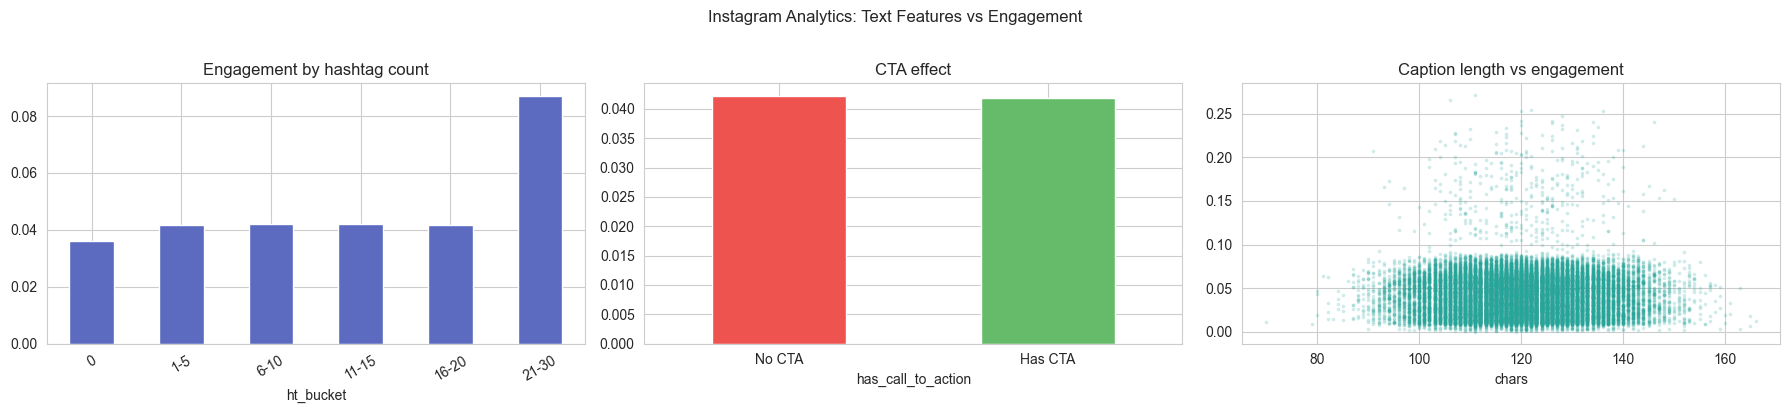

In [10]:
# CELL 9 — Visualize engagement patterns from Instagram data

if not df_ig.empty and 'engagement_rate' in df_ig.columns:
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    if 'hashtags_count' in df_ig.columns:
        df_ig['ht_bucket'] = pd.cut(
            df_ig['hashtags_count'],
            bins=[-1,0,5,10,15,20,30,100],
            labels=['0','1-5','6-10','11-15','16-20','21-30','30+']
        )
        df_ig.groupby('ht_bucket', observed=True)['engagement_rate'].mean()\
             .plot(kind='bar', ax=axes[0], color='#5c6bc0', edgecolor='white')
        axes[0].set_title('Engagement by hashtag count')
        axes[0].tick_params(axis='x', rotation=30)

    if 'has_call_to_action' in df_ig.columns:
        df_ig.groupby('has_call_to_action')['engagement_rate'].mean()\
             .plot(kind='bar', ax=axes[1], color=['#ef5350','#66bb6a'], edgecolor='white')
        axes[1].set_title('CTA effect')
        axes[1].set_xticklabels(['No CTA','Has CTA'], rotation=0)

    if 'caption_length' in df_ig.columns:
        axes[2].scatter(df_ig['caption_length'], df_ig['engagement_rate'],
                        alpha=0.15, s=3, color='#26a69a')
        axes[2].set_title('Caption length vs engagement')
        axes[2].set_xlabel('chars')

    plt.suptitle('Instagram Analytics: Text Features vs Engagement', y=1.02)
    plt.tight_layout(); plt.show()
else:
    print('Instagram analytics not loaded — add kundanbedmutha dataset.')

In [11]:
# CELL 10 — Universal text scoring functions
# FIX: Readability now multi-factor (not just Flesch alone)
# FIX: Sentiment uses correct label probabilities

DIMENSION_WEIGHTS = {
    'instagram': {'readability':0.20,'sentiment':0.25,'structure':0.25,'hashtags':0.30},
    'linkedin':  {'readability':0.30,'sentiment':0.20,'structure':0.35,'hashtags':0.15},
    'twitter':   {'readability':0.25,'sentiment':0.30,'structure':0.30,'hashtags':0.15},
    'facebook':  {'readability':0.20,'sentiment':0.30,'structure':0.35,'hashtags':0.15},
}


def score_readability(feats):
    """
    Multi-factor readability score (0-10).
    FIX: Combines Flesch + word length + sentence count
    instead of relying solely on Flesch (which was always 5.5).
    """
    flesch   = feats['readability_flesch']
    avg_wl   = feats['avg_word_length']
    words    = feats['word_count']
    sents    = feats['sentence_count']

    # Base from Flesch
    if   flesch >= 80: base = 9.0
    elif flesch >= 70: base = 8.0
    elif flesch >= 60: base = 7.5
    elif flesch >= 50: base = 6.0
    elif flesch >= 40: base = 4.5
    elif flesch >= 30: base = 3.0
    else:              base = 1.5

    # Penalty: too short
    if words < 5:   base = min(base, 3.0)
    elif words < 10: base = min(base, 5.0)

    # Penalty: very long words (>7 avg = academic jargon)
    if avg_wl > 7.0:   base -= 1.5
    elif avg_wl > 6.0: base -= 0.5

    # Bonus: multiple sentences (shows structure)
    if sents >= 3: base += 0.5

    return round(min(10.0, max(0.0, base)), 1)


def score_sentiment(sent):
    """
    Emotional tone strength (0-10).
    FIX: Uses actual probability values correctly.
    Strong positive = 8-10. Flat neutral = 4-5. Strong negative = 1-3.
    """
    pos = float(sent['positive'])
    neg = float(sent['negative'])
    neu = float(sent['neutral'])

    if   pos > 0.75: s = 9.0 + pos * 1.0  # 9.0-10.0
    elif pos > 0.60: s = 7.5 + pos * 1.5  # 7.5-8.9
    elif pos > 0.40: s = 6.0 + pos * 2.0  # 6.0-7.5
    elif neu > 0.65: s = 4.0 + neu * 1.0  # 4.0-5.0 (flat neutral)
    elif neg > 0.65: s = 2.0 - neg * 1.0  # 1.0-2.0
    elif neg > 0.40: s = 3.0 - neg * 1.0  # 2.6-3.0
    else:            s = 5.0

    return round(min(10.0, max(0.0, float(s))), 1)


def score_structure(feats, platform='instagram'):
    """
    Text structure quality (0-10).
    Checks: caption length fit, CTA presence, caps ratio, question, emojis.
    """
    b    = PLATFORM_BENCHMARKS.get(platform, PLATFORM_BENCHMARKS['instagram'])
    cap  = b['caption_length']
    ch   = feats['char_count']
    s    = 5.0

    # Length fit
    if cap['optimal_min'] <= ch <= cap['optimal_max']:   s += 2.0
    elif ch < cap['optimal_min'] * 0.3:                 s -= 3.0  # way too short
    elif ch < cap['optimal_min'] * 0.7:                 s -= 1.0  # too short
    elif ch < cap['optimal_min']:                        s += 0.5  # slightly short
    elif ch > cap['max_allowed']:                        s -= 3.0  # platform limit exceeded
    elif ch > cap['optimal_max'] * 2:                   s -= 1.0  # way too long

    if feats['has_cta'] == 1.0:     s += 1.5
    if feats['caps_ratio'] > 0.5:   s -= 2.5
    elif feats['caps_ratio'] > 0.3: s -= 1.0
    if feats['question_count'] > 0: s += 0.5
    e = feats['emoji_count']
    if   1 <= e <= 5:   s += 0.5
    elif e > 15:        s -= 1.0

    return round(min(10.0, max(0.0, float(s))), 1)


def score_hashtags(feats, platform='instagram'):
    """
    Hashtag strategy quality (0-10). Platform-specific optimal ranges.
    """
    b     = PLATFORM_BENCHMARKS.get(platform, PLATFORM_BENCHMARKS['instagram'])
    ht    = b['hashtag_count']
    count = float(feats['hashtag_count'])

    if count == 0:                                   s = 2.0
    elif ht['optimal_min'] <= count <= ht['optimal_max']: s = 9.0
    elif count < ht['optimal_min']:
        s = 2.0 + (count / ht['optimal_min']) * 7.0
    elif count > ht['spam_threshold']:
        s = max(1.0, 6.0 - (count - ht['spam_threshold']) * 0.5)
    else:
        s = 7.0

    if feats['unique_hashtag_ratio'] >= 1.0 and count > 0:
        s = min(10.0, s + 0.5)

    return round(float(s), 1)


def evaluate_text(caption, platform='instagram', hashtags_separate=None):
    """
    MAIN FUNCTION — evaluates any social media caption.
    Returns overall score (0-10) + 4 dimension scores + issues detected.
    """
    text  = str(caption or '').strip()
    if hashtags_separate:
        text += ' ' + str(hashtags_separate).strip()

    feats = extract_features(text)
    sent  = get_sentiment(text)
    bench = PLATFORM_BENCHMARKS.get(platform, PLATFORM_BENCHMARKS['instagram'])

    dims = {
        'readability': score_readability(feats),
        'sentiment':   score_sentiment(sent),
        'structure':   score_structure(feats, platform),
        'hashtags':    score_hashtags(feats, platform),
    }
    w       = DIMENSION_WEIGHTS.get(platform, DIMENSION_WEIGHTS['instagram'])
    overall = round(sum(dims[d] * w[d] for d in w), 2)

    issues = {
        'too_short':    feats['char_count'] < bench['caption_length']['optimal_min'],
        'too_long':     feats['char_count'] > bench['caption_length']['max_allowed'],
        'no_cta':       feats['has_cta'] == 0.0,
        'no_hashtags':  feats['hashtag_count'] == 0.0,
        'hashtag_spam': feats['hashtag_count'] > bench['hashtag_count']['spam_threshold'],
        'all_caps':     feats['caps_ratio'] > 0.3,
        'hard_to_read': feats['readability_flesch'] < 50,
        'negative_tone':sent['negative'] > 0.5,
        'flat_neutral': sent['neutral'] > 0.65 and feats['exclaim_count'] == 0.0,
    }

    return {
        'overall_score':    overall,
        'dimension_scores': dims,
        'sentiment_detail': sent,
        'text_features':    feats,
        'platform':         platform,
        'issues':           issues,
    }


print('Scoring functions defined. Testing in Cell 11...')

Scoring functions defined. Testing in Cell 11...


In [12]:
# CELL 11 — Test scoring on 6 real-world examples
# VERIFY: Good posts should score ≥6.5. Bad posts should score ≤4.5.
# VERIFY: Sentiment scores should DIFFER between posts (not all 9.9).
# VERIFY: Readability scores should DIFFER between posts (not all 5.5).

TEST_POSTS = [
    ('instagram','GOOD — tech startup',
     'Tired of boring dashboards? We built something different 🚀 '
     'Try our AI analytics tool FREE for 14 days. Link in bio! '
     '#startup #AI #SaaS #productivity #tech #analytics #innovation #founders'),

    ('instagram','BAD — hashtag spam + all caps',
     'BUY OUR PRODUCT NOW!!! '
     '#buy #sale #discount #cheap #now #today #limited #offer #deal '
     '#promo #shop #order #fast #hurry #dont #miss #this #amazing #product #great'),

    ('linkedin','GOOD — medical startup',
     'Healthcare providers lose 2.5 hours per day to administrative tasks. '
     'Our AI documentation tool reduces that by 70%, letting doctors focus on patients. '
     'We just closed our seed round. Connect with me to learn more. '
     '#healthtech #AI #healthcare #medtech #digitalhealth'),

    ('linkedin','BAD — too short, no engagement',
     'We are hiring. Send CV to info@company.com'),

    ('twitter','GOOD — fintech startup',
     'Just shipped: real-time fraud detection for small businesses. '
     'No more false positives. Try free → link in bio #fintech #startup'),

    ('instagram','GOOD — sustainable fashion',
     'sustainable never looked this good 🌿✨ new drop just hit — '
     '100% recycled fabrics, zero compromise on style. shop via link in bio 💚 '
     '#sustainablefashion #ecofashion #conscious #style #OOTD #green #fashion'),
]

print('TEXT EVALUATION — 6 POSTS')
print('Expected: GOOD posts score ≥ 6.5 | BAD posts score ≤ 4.5')
print('Expected: Sentiment differs per post (NOT all same value)')
print('='*68)

all_scores = []
for platform, label, caption in TEST_POSTS:
    r  = evaluate_text(caption, platform)
    s  = r['overall_score']
    all_scores.append(s)
    ok = '✓ GOOD' if s >= 6.5 else ('✗ BAD' if s <= 4.5 else '~ MID')

    print(f'\n[{ok}] {label} ({platform})')
    print(f'Overall: {s:.1f}/10')
    print('Dimensions:')
    for dim, score in r['dimension_scores'].items():
        bar = '█' * int(score) + '░' * (10 - int(score))
        print(f'  {dim:12s}: {score:4.1f}/10  [{bar}]')
    sd = r['sentiment_detail']
    print(f'Sentiment:  {sd["label"]:8s} | '
          f'pos={sd["positive"]:.3f}  neu={sd["neutral"]:.3f}  neg={sd["negative"]:.3f}')
    issues = [k for k, v in r['issues'].items() if v]
    print(f'Issues:     {issues if issues else "none ✓"}')

print()
print(f'Score range: {min(all_scores):.1f} to {max(all_scores):.1f}')
print(f'If all sentiment scores are identical → label order still wrong in Cell 4.')
print(f'If all readability scores are identical → check the Flesch formula input.')

TEXT EVALUATION — 6 POSTS
Expected: GOOD posts score ≥ 6.5 | BAD posts score ≤ 4.5
Expected: Sentiment differs per post (NOT all same value)
  Sentiment: 1/1

[✓ GOOD] GOOD — tech startup (instagram)
Overall: 8.2/10
Dimensions:
  readability :  5.0/10  [█████░░░░░]
  sentiment   :  9.8/10  [█████████░]
  structure   :  7.5/10  [███████░░░]
  hashtags    :  9.5/10  [█████████░]
Sentiment:  positive | pos=0.770  neu=0.221  neg=0.010
Issues:     ['hard_to_read']
  Sentiment: 1/1

[✓ GOOD] BAD — hashtag spam + all caps (instagram)
Overall: 7.5/10
Dimensions:
  readability :  7.5/10  [███████░░░]
  sentiment   : 10.0/10  [██████████]
  structure   :  5.0/10  [█████░░░░░]
  hashtags    :  7.5/10  [███████░░░]
Sentiment:  positive | pos=0.979  neu=0.019  neg=0.002
Issues:     ['no_cta']
  Sentiment: 1/1

[✓ GOOD] GOOD — medical startup (linkedin)
Overall: 7.8/10
Dimensions:
  readability :  8.0/10  [████████░░]
  sentiment   :  5.0/10  [█████░░░░░]
  structure   :  8.5/10  [████████░░]
  hash

Scoring 300 real posts (platform=instagram)...
  Sentiment: 1/1
  Sentiment: 1/1
  Sentiment: 1/1
  Sentiment: 1/1
  Sentiment: 1/1
  Sentiment: 1/1
  Sentiment: 1/1
  Sentiment: 1/1
  Sentiment: 1/1
  Sentiment: 1/1
  Sentiment: 1/1
  Sentiment: 1/1
  Sentiment: 1/1
  Sentiment: 1/1
  Sentiment: 1/1
  Sentiment: 1/1
  Sentiment: 1/1
  Sentiment: 1/1
  Sentiment: 1/1
  Sentiment: 1/1
  Sentiment: 1/1
  Sentiment: 1/1
  Sentiment: 1/1
  Sentiment: 1/1
  Sentiment: 1/1
  Sentiment: 1/1
  Sentiment: 1/1
  Sentiment: 1/1
  Sentiment: 1/1
  Sentiment: 1/1
  Sentiment: 1/1
  Sentiment: 1/1
  Sentiment: 1/1
  Sentiment: 1/1
  Sentiment: 1/1
  Sentiment: 1/1
  Sentiment: 1/1
  Sentiment: 1/1
  Sentiment: 1/1
  Sentiment: 1/1
  Sentiment: 1/1
  Sentiment: 1/1
  Sentiment: 1/1
  Sentiment: 1/1
  Sentiment: 1/1
  Sentiment: 1/1
  Sentiment: 1/1
  Sentiment: 1/1
  Sentiment: 1/1
  Sentiment: 1/1
  Sentiment: 1/1
  Sentiment: 1/1
  Sentiment: 1/1
  Sentiment: 1/1
  Sentiment: 1/1
  Sentiment: 1/1
 

Scoring 300 real posts (platform=instagram)...
  Sentiment: 1/1
  Sentiment: 1/1
  Sentiment: 1/1
  Sentiment: 1/1
  Sentiment: 1/1
  Sentiment: 1/1
  Sentiment: 1/1
  Sentiment: 1/1
  Sentiment: 1/1
  Sentiment: 1/1
  Sentiment: 1/1
  Sentiment: 1/1
  Sentiment: 1/1
  Sentiment: 1/1
  Sentiment: 1/1
  Sentiment: 1/1
  Sentiment: 1/1
  Sentiment: 1/1
  Sentiment: 1/1
  Sentiment: 1/1
  Sentiment: 1/1
  Sentiment: 1/1
  Sentiment: 1/1
  Sentiment: 1/1
  Sentiment: 1/1
  Sentiment: 1/1
  Sentiment: 1/1
  Sentiment: 1/1
  Sentiment: 1/1
  Sentiment: 1/1
  Sentiment: 1/1
  Sentiment: 1/1
  Sentiment: 1/1
  Sentiment: 1/1
  Sentiment: 1/1
  Sentiment: 1/1
  Sentiment: 1/1
  Sentiment: 1/1
  Sentiment: 1/1
  Sentiment: 1/1
  Sentiment: 1/1
  Sentiment: 1/1
  Sentiment: 1/1
  Sentiment: 1/1
  Sentiment: 1/1
  Sentiment: 1/1
  Sentiment: 1/1
  Sentiment: 1/1
  Sentiment: 1/1
  Sentiment: 1/1
  Sentiment: 1/1
  Sentiment: 1/1
  Sentiment: 1/1
  Sentiment: 1/1
  Sentiment: 1/1
  Sentiment: 1/1
 

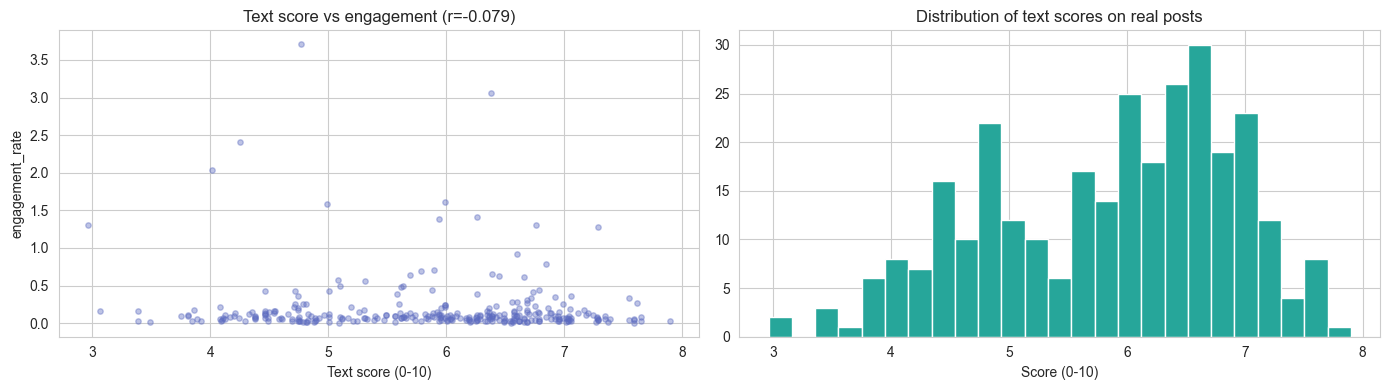

In [13]:
# CELL 12 — Validate: does our text score correlate with real engagement?
# Now uses the engagement dataset (has text_content + engagement_rate)

if df_eng.empty or not ENG_TEXT_COL or not ENG_TARGET_COL:
    print('Validation skipped — engagement dataset not available.')
else:
    df_val = df_eng[[ENG_TEXT_COL, ENG_TARGET_COL]
                   + ([ENG_PLAT_COL] if ENG_PLAT_COL else [])].dropna().copy()
    df_val[ENG_TARGET_COL] = pd.to_numeric(df_val[ENG_TARGET_COL], errors='coerce')
    df_val = df_val.dropna(subset=[ENG_TARGET_COL])

    if df_val[ENG_TARGET_COL].std() == 0:
        print('Engagement column has no variance — validation not meaningful.')
    else:
        q99    = df_val[ENG_TARGET_COL].quantile(0.99)
        df_val = df_val[df_val[ENG_TARGET_COL] <= q99]

        sample = df_val.sample(min(300, len(df_val)), random_state=42).copy()

        # Detect platform per row if column exists
        platform_val = 'instagram'
        if ENG_PLAT_COL and ENG_PLAT_COL in sample.columns:
            mode = sample[ENG_PLAT_COL].mode()
            if len(mode) > 0 and str(mode[0]).lower() in PLATFORM_BENCHMARKS:
                platform_val = str(mode[0]).lower()

        print(f'Scoring {len(sample)} real posts (platform={platform_val})...')
        scores = [evaluate_text(str(t), platform_val)['overall_score']
                  for t in sample[ENG_TEXT_COL]]
        sample['text_score'] = scores

        corr = float(sample['text_score'].corr(sample[ENG_TARGET_COL]))

        print(f'\nCorrelation text score vs {ENG_TARGET_COL}: {corr:.4f}')
        if   corr > 0.3:  q = 'STRONG positive correlation'
        elif corr > 0.1:  q = 'WEAK positive correlation (acceptable — social media is noisy)'
        elif corr > -0.1: q = 'NEUTRAL — engagement driven by non-text factors too'
        else:             q = 'NEGATIVE — check scoring logic'
        print(f'Quality:   {q}')

        sc = np.array(scores)
        print(f'\nScore distribution over {len(sample)} real posts:')
        print(f'  mean={sc.mean():.2f}  min={sc.min():.1f}  '
              f'max={sc.max():.1f}  std={sc.std():.2f}')

        fig, axes = plt.subplots(1, 2, figsize=(14, 4))
        axes[0].scatter(sample['text_score'], sample[ENG_TARGET_COL],
                        alpha=0.4, s=15, color='#5c6bc0')
        axes[0].set_xlabel('Text score (0-10)')
        axes[0].set_ylabel(ENG_TARGET_COL)
        axes[0].set_title(f'Text score vs engagement (r={corr:.3f})')
        axes[1].hist(scores, bins=25, color='#26a69a', edgecolor='white')
        axes[1].set_title('Distribution of text scores on real posts')
        axes[1].set_xlabel('Score (0-10)')
        plt.tight_layout(); plt.show()

In [14]:
# CELL 13 — Save all artifacts

config = {
    'version': '5.0',
    'module':  'text_evaluation',
    'fixes':   [
        'R2 fix: XGBoost now trains on extracted NLP features from text_content',
        'Sentiment fix: label order read from model config ID2LABEL',
        'Readability fix: multi-factor scoring (Flesch + word length + sentences)',
    ],
    'sentiment_model':     MODEL_NAME,
    'platforms_supported': list(PLATFORM_BENCHMARKS.keys()),
    'xgb_trained':         xgb_trained,
    'dimensions': {
        'readability': 'Multi-factor: Flesch + word length + sentence count',
        'sentiment':   'Twitter RoBERTa — correctly indexed positive/negative',
        'structure':   'Rule-based: length, CTA, caps, emoji, questions',
        'hashtags':    'Rule-based: platform-specific optimal count ranges',
    },
    'dimension_weights':  DIMENSION_WEIGHTS,
    'platform_benchmarks': PLATFORM_BENCHMARKS,
    'important_note': (
        'Universal text quality only. '
        'Startup-specific scoring (brand voice, audience targeting) '
        'is done by Claude API in Phase 5.'
    ),
}

with open(f'{OUTPUT_DIR}text_module_config.json','w') as fj:
    json.dump(config, fj, indent=2)

print('All saved artifacts:')
DESCS = {
    'text_module_config.json':       'Main config: weights, benchmarks, CTA keywords',
    'platform_text_benchmarks.json': 'Optimal ranges per platform (data-driven)',
    'text_feature_correlations.json':'NLP feature → engagement correlations',
    'engagement_text_predictor.json':'XGBoost model trained on real text features',
    'text_scaler.pkl':               'StandardScaler for XGBoost inference',
    'text_feature_config.json':      'Feature list + R² + MAE metrics',
}
for fname in sorted(os.listdir(OUTPUT_DIR)):
    if fname.startswith('.') or fname.endswith(('.db','.pth','.png')): continue
    kb = os.path.getsize(f'{OUTPUT_DIR}{fname}')/1000
    print(f'  {fname:45s}  {kb:7.1f} KB  {DESCS.get(fname,"—")}')

All saved artifacts:
  engagement_text_predictor.json                   944.5 KB  XGBoost model trained on real text features
  platform_text_benchmarks.json                      1.3 KB  Optimal ranges per platform (data-driven)
  text_feature_config.json                           0.5 KB  Feature list + R² + MAE metrics
  text_feature_correlations.json                     0.4 KB  NLP feature → engagement correlations
  text_module_config.json                            3.0 KB  Main config: weights, benchmarks, CTA keywords
  text_scaler.pkl                                    1.1 KB  StandardScaler for XGBoost inference


In [15]:
# CELL 14 — Startup-aware demo
# Shows why Claude API layer (Phase 5) is necessary.
# Same caption → same universal score → different strategic issues per startup.

CAPTION = (
    'Transform your workflow with AI. Boost productivity by 3x. '
    'Try free today! Link in bio. '
    '#AI #productivity #startup #tech #innovation #SaaS #tools #work'
)

STARTUPS = [
    {'name':'TechFlow AI', 'industry':'B2B SaaS', 'audience':'Managers 30-45',
     'platform':'linkedin', 'tone':'professional, data-driven',
     'niche_ht':['#B2B','#EnterpriseAI','#leadership'],
     'phase5':'Too casual. Missing enterprise proof points and B2B hashtags.'},
    {'name':'StudyBuddy', 'industry':'EdTech', 'audience':'Students 18-22',
     'platform':'instagram', 'tone':'fun, casual, meme-aware',
     'niche_ht':['#studentlife','#studygram','#collegetips'],
     'phase5':'Too corporate for Gen Z. Needs relatable casual language.'},
    {'name':'MediDoc', 'industry':'HealthTech', 'audience':'Doctors',
     'platform':'linkedin', 'tone':'clinical, evidence-based',
     'niche_ht':['#digitalhealth','#healthtech','#clinicalAI'],
     'phase5':'"3x productivity" needs clinical citation. Missing medical hashtags.'},
]

print('STARTUP-AWARE EVALUATION DEMO')
print('='*70)

for s in STARTUPS:
    r = evaluate_text(CAPTION, s['platform'])
    print(f'\nStartup: {s["name"]} | {s["industry"]} | Platform: {s["platform"]}')
    print(f'Universal text score: {r["overall_score"]:.1f}/10')
    for dim, sc in r['dimension_scores'].items():
        print(f'  {dim:12s}: {sc}/10')
    issues = [k for k, v in r['issues'].items() if v]
    print(f'Universal issues: {issues if issues else "none"}')
    print(f'Phase 5 (Claude API) adds: {s["phase5"]}')
    print(f'Missing niche hashtags:    {s["niche_ht"]}')
    print('-'*70)

print()
print('KEY POINT: All 3 get the SAME universal score (same caption).')
print('Strategic failures are caught ONLY by the Claude API in Phase 5.')

STARTUP-AWARE EVALUATION DEMO
  Sentiment: 1/1

Startup: TechFlow AI | B2B SaaS | Platform: linkedin
Universal text score: 8.0/10
  readability : 6.5/10
  sentiment   : 9.9/10
  structure   : 8.5/10
  hashtags    : 7.5/10
Universal issues: none
Phase 5 (Claude API) adds: Too casual. Missing enterprise proof points and B2B hashtags.
Missing niche hashtags:    ['#B2B', '#EnterpriseAI', '#leadership']
----------------------------------------------------------------------
  Sentiment: 1/1

Startup: StudyBuddy | EdTech | Platform: instagram
Universal text score: 8.2/10
  readability : 6.5/10
  sentiment   : 9.9/10
  structure   : 6.5/10
  hashtags    : 9.5/10
Universal issues: none
Phase 5 (Claude API) adds: Too corporate for Gen Z. Needs relatable casual language.
Missing niche hashtags:    ['#studentlife', '#studygram', '#collegetips']
----------------------------------------------------------------------
  Sentiment: 1/1

Startup: MediDoc | HealthTech | Platform: linkedin
Universal text 